# Data Extraction

In [29]:
import obspy, io
from pathlib import Path

### Opening large mseed files
`obspy.read()` cannot directly read mini-SEED files that are larger than 2048 MB. Read the file in chunks instead ([link](https://github.com/obspy/obspy/pull/1419#issuecomment-221582369) to github issue).

Note on `record_len`: A record is a unit of data in the miniSEED format. A record consists of a certain number of data points in the waveform. Typical record lengths for raw data generation and archiving are between 256 and 4096 bytes ([FDSN docs](https://docs.fdsn.org/projects/miniseed3/en/latest/definition.html#:~:text=typical%20record%20lengths%20for%20raw%20data%20generation%20and%20archiving%20are%20recommended%20to%20be%20in%20the%20range%20of%20256%20and%204096%20bytes)).

In [ ]:
mseed_filename = "HE_020125_030125.mseed" # Queried from ISUH FDSNWS. It is a 3.7GB file containing waveforms from HE network from 2-3 Jan 2025
data_dir = Path("data")

record_len = 512
chunksize = 100000 * record_len
with io.open(data_dir / mseed_filename, "rb") as fh:
    while True:
        with io.BytesIO() as buf:
            c = fh.read(chunksize)
            if not c:
                break
            buf.write(c)
            buf.seek(0, 0)
            st = obspy.read(buf)
        # Do something useful!
        print(st)
        break # We just want to see the first stream from the mseed file

2 Trace(s) in Stream:
HE.OBF8..HHE | 2025-01-01T23:59:59.568000Z - 2025-01-03T00:00:00.748000Z | 250.0 Hz, 21600296 samples
HE.OBF8..HHN | 2025-01-01T23:59:58.808000Z - 2025-01-02T07:26:55.188000Z | 250.0 Hz, 6704096 samples


### Querying waveform data from ISUH FDSNWS

To query ISUH FDSNWS dataselect service, ensure your device is connected to the university's network. Eduroam does not work, but wired connections on devices at the university do.

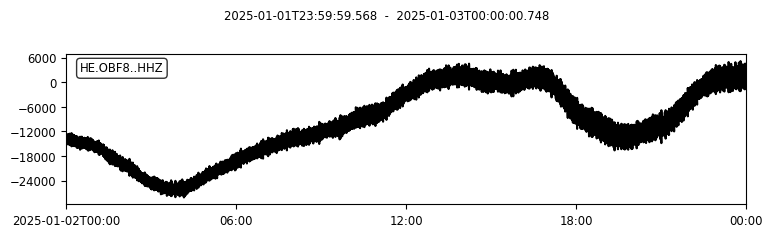

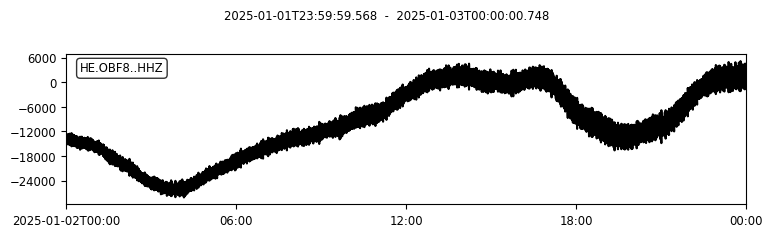

In [31]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime


client = Client("http://128.214.169.201:8080") # ISUH FDSNWS IP address

start_time = UTCDateTime("2025-01-01T23:59:59.568000Z")
end_time = UTCDateTime("2025-01-03T00:00:00.748000Z")

st = client.get_waveforms("HE", "OBF8", "*", "HHZ", start_time, end_time)

st.plot()